In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import the os module

# --- Load CSV ---
df = pd.read_csv("/content/sp500_index.csv", parse_dates=["Date"])

# --- Create database directory if it doesn't exist ---
db_dir = "db"
if not os.path.exists(db_dir):
    os.makedirs(db_dir)
    print(f"Created directory: {db_dir}/")

# --- Load into SQLite ---
conn = sqlite3.connect(f"{db_dir}/sp500.db") # Use f-string for clarity
df.to_sql("sp500", conn, if_exists="replace", index=False)
print("Data loaded into SQLite ✓")

# --- Quick SQL query: yearly averages ---
query = """
    SELECT
        strftime('%Y', Date) AS year,
        ROUND(AVG("S&P500"), 2) AS avg_index,
        ROUND(MIN("S&P500"), 2) AS min_index,
        ROUND(MAX("S&P500"), 2) AS max_index
    FROM sp500
    GROUP BY year
    ORDER BY year
"""
yearly = pd.read_sql_query(query, conn)
print(yearly)

conn.close()

Data loaded into SQLite ✓
    year  avg_index  min_index  max_index
0   2014    2080.17    2058.90    2090.57
1   2015    2061.07    1867.61    2130.82
2   2016    2094.65    1829.08    2271.72
3   2017    2449.08    2257.83    2690.16
4   2018    2746.21    2351.10    2930.75
5   2019    2913.36    2447.89    3240.02
6   2020    3217.86    2237.40    3756.07
7   2021    4273.41    3700.65    4793.06
8   2022    4098.51    3577.03    4796.56
9   2023    4283.73    3808.10    4783.35
10  2024    5415.06    4688.68    6090.27


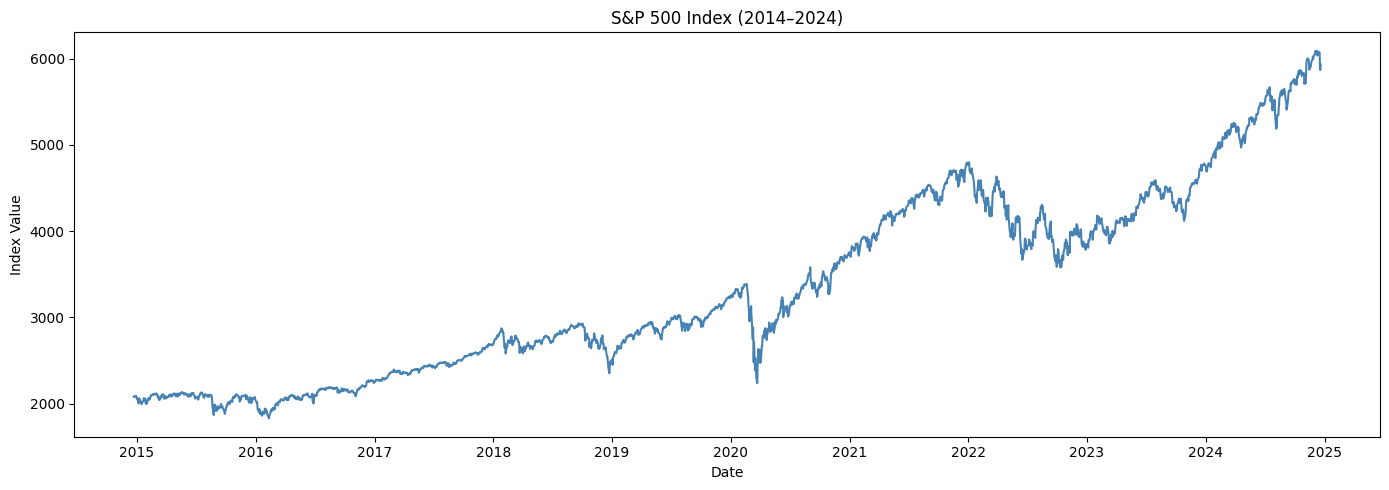

In [8]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x="Date", y="S&P500", color="steelblue")
plt.title("S&P 500 Index (2014–2024)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.tight_layout()
plt.savefig("sp500_trend.png")
plt.show()

**S&P500 year by year comparison:**

In [9]:
# Year-by-year performance
conn = sqlite3.connect("db/sp500.db")

query = """
    SELECT
        strftime('%Y', Date) AS year,
        ROUND(MIN(S&P500), 2) AS start_value,  -- first trading day
        ROUND(MAX(CASE WHEN Date = (
            SELECT MAX(Date) FROM sp500 s2
            WHERE strftime('%Y', s2.Date) = strftime('%Y', sp500.Date)
        ) THEN S&P500 END), 2) AS end_value
    FROM sp500
    GROUP BY year
    ORDER BY year
"""

# Simpler approach using pandas
df = pd.read_sql_query("SELECT * FROM sp500", conn)
conn.close()

df["Date"] = pd.to_datetime(df["Date"])
df["year"] = df["Date"].dt.year

# Get first and last value per year
yearly = df.groupby("year")["S&P500"].agg(["first", "last"]).reset_index()
yearly.columns = ["year", "start", "end"]
yearly["return_pct"] = ((yearly["end"] - yearly["start"]) / yearly["start"] * 100).round(2)
yearly["positive"] = yearly["return_pct"] > 0

print(yearly[["year", "start", "end", "return_pct"]])

    year    start      end  return_pct
0   2014  2078.54  2058.90       -0.94
1   2015  2058.20  2043.94       -0.69
2   2016  2012.66  2238.83       11.24
3   2017  2257.83  2673.61       18.42
4   2018  2695.81  2506.85       -7.01
5   2019  2510.03  3230.78       28.71
6   2020  3257.85  3756.07       15.29
7   2021  3700.65  4766.18       28.79
8   2022  4796.56  3839.50      -19.95
9   2023  3824.14  4769.83       24.73
10  2024  4742.83  5930.85       25.05


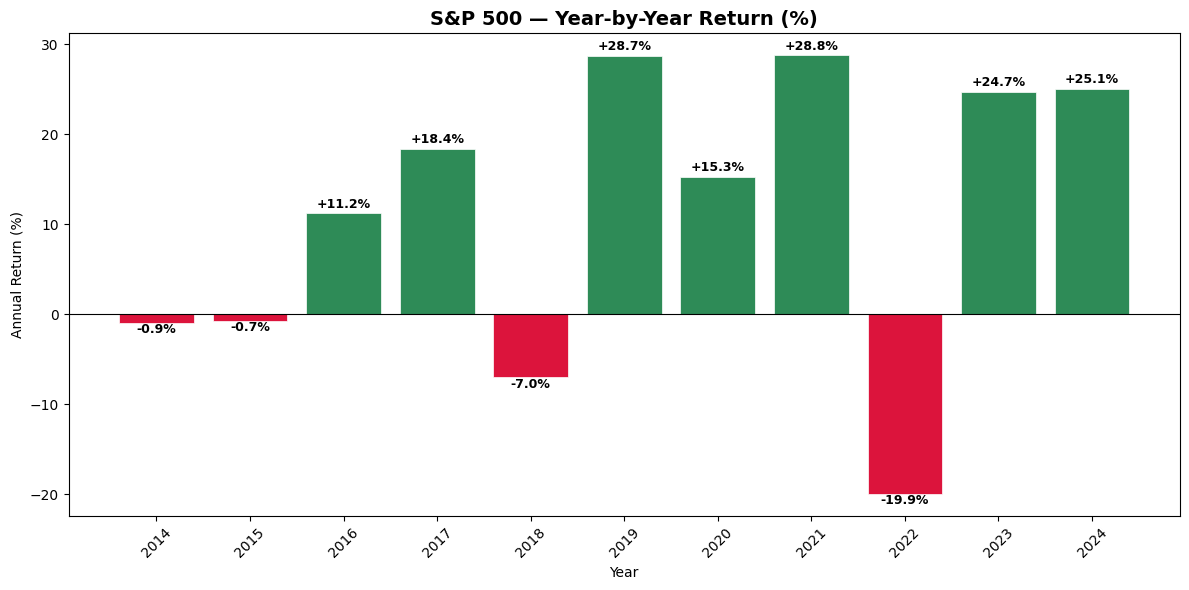

In [10]:
plt.figure(figsize=(12, 6))
colors = ["seagreen" if pos else "crimson" for pos in yearly["positive"]]
bars = plt.bar(yearly["year"], yearly["return_pct"], color=colors, edgecolor="white", linewidth=0.5)

# Add value labels on each bar
for bar, val in zip(bars, yearly["return_pct"]):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
    plt.text(bar.get_x() + bar.get_width() / 2, ypos, f"{val:+.1f}%",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.axhline(0, color="black", linewidth=0.8)
plt.title("S&P 500 — Year-by-Year Return (%)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Annual Return (%)")
plt.xticks(yearly["year"], rotation=45)
plt.tight_layout()
plt.savefig("sp500_yearly_returns.png")
plt.show()

**Moving averages:**

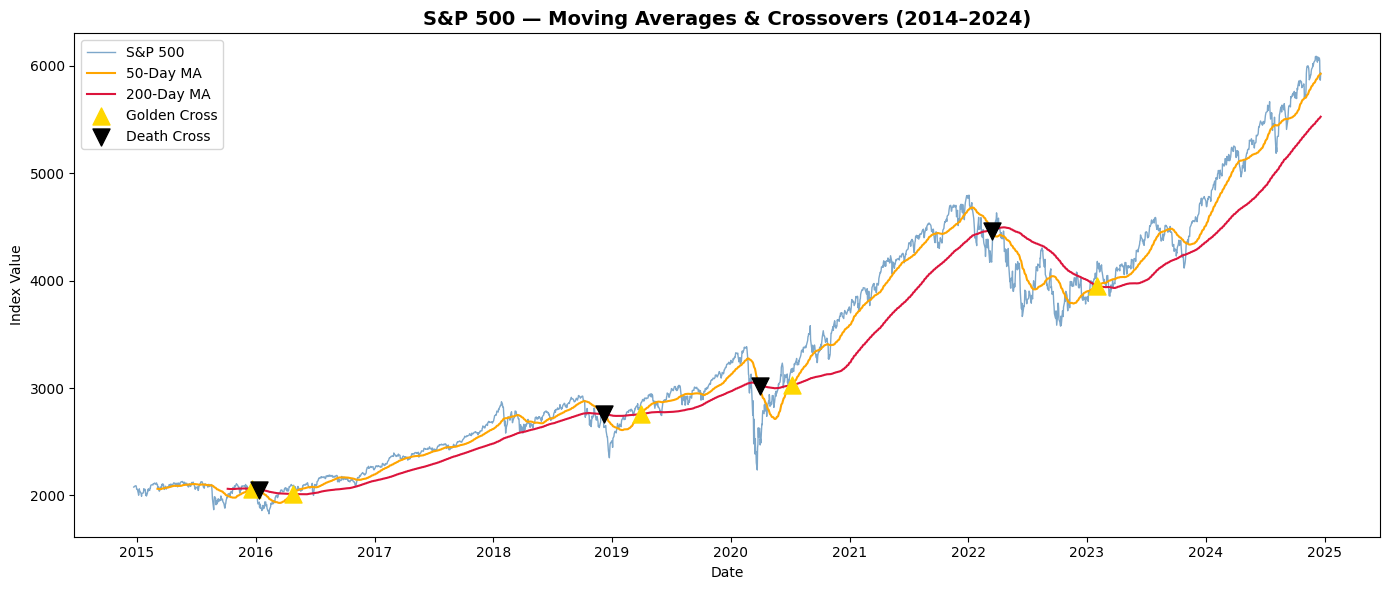

In [11]:
# Moving Averages
conn = sqlite3.connect("db/sp500.db")
df = pd.read_sql_query("SELECT * FROM sp500", conn)
conn.close()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Calculate moving averages
df["MA50"] = df["S&P500"].rolling(window=50).mean()
df["MA200"] = df["S&P500"].rolling(window=200).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["S&P500"], label="S&P 500", color="steelblue", linewidth=1, alpha=0.7)
plt.plot(df["Date"], df["MA50"], label="50-Day MA", color="orange", linewidth=1.5)
plt.plot(df["Date"], df["MA200"], label="200-Day MA", color="crimson", linewidth=1.5)

# Highlight Golden Cross moments
golden = df[(df["MA50"] > df["MA200"]) & (df["MA50"].shift(1) <= df["MA200"].shift(1))]
death = df[(df["MA50"] < df["MA200"]) & (df["MA50"].shift(1) >= df["MA200"].shift(1))]

plt.scatter(golden["Date"], golden["MA50"], marker="^", color="gold",
            zorder=5, s=150, label="Golden Cross")
plt.scatter(death["Date"], death["MA50"], marker="v", color="black",
            zorder=5, s=150, label="Death Cross")

plt.title("S&P 500 — Moving Averages & Crossovers (2014–2024)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
plt.savefig("sp500_moving_averages.png")
plt.show()

Daily return = how much the index moved that day as a percentage. e.g. if it went from 5000 → 5050, that's a +1% return

Volatility = How "wild" the market is swinging. High volatility = uncertain, scary markets (think COVID). Low volatility = calm, steady markets

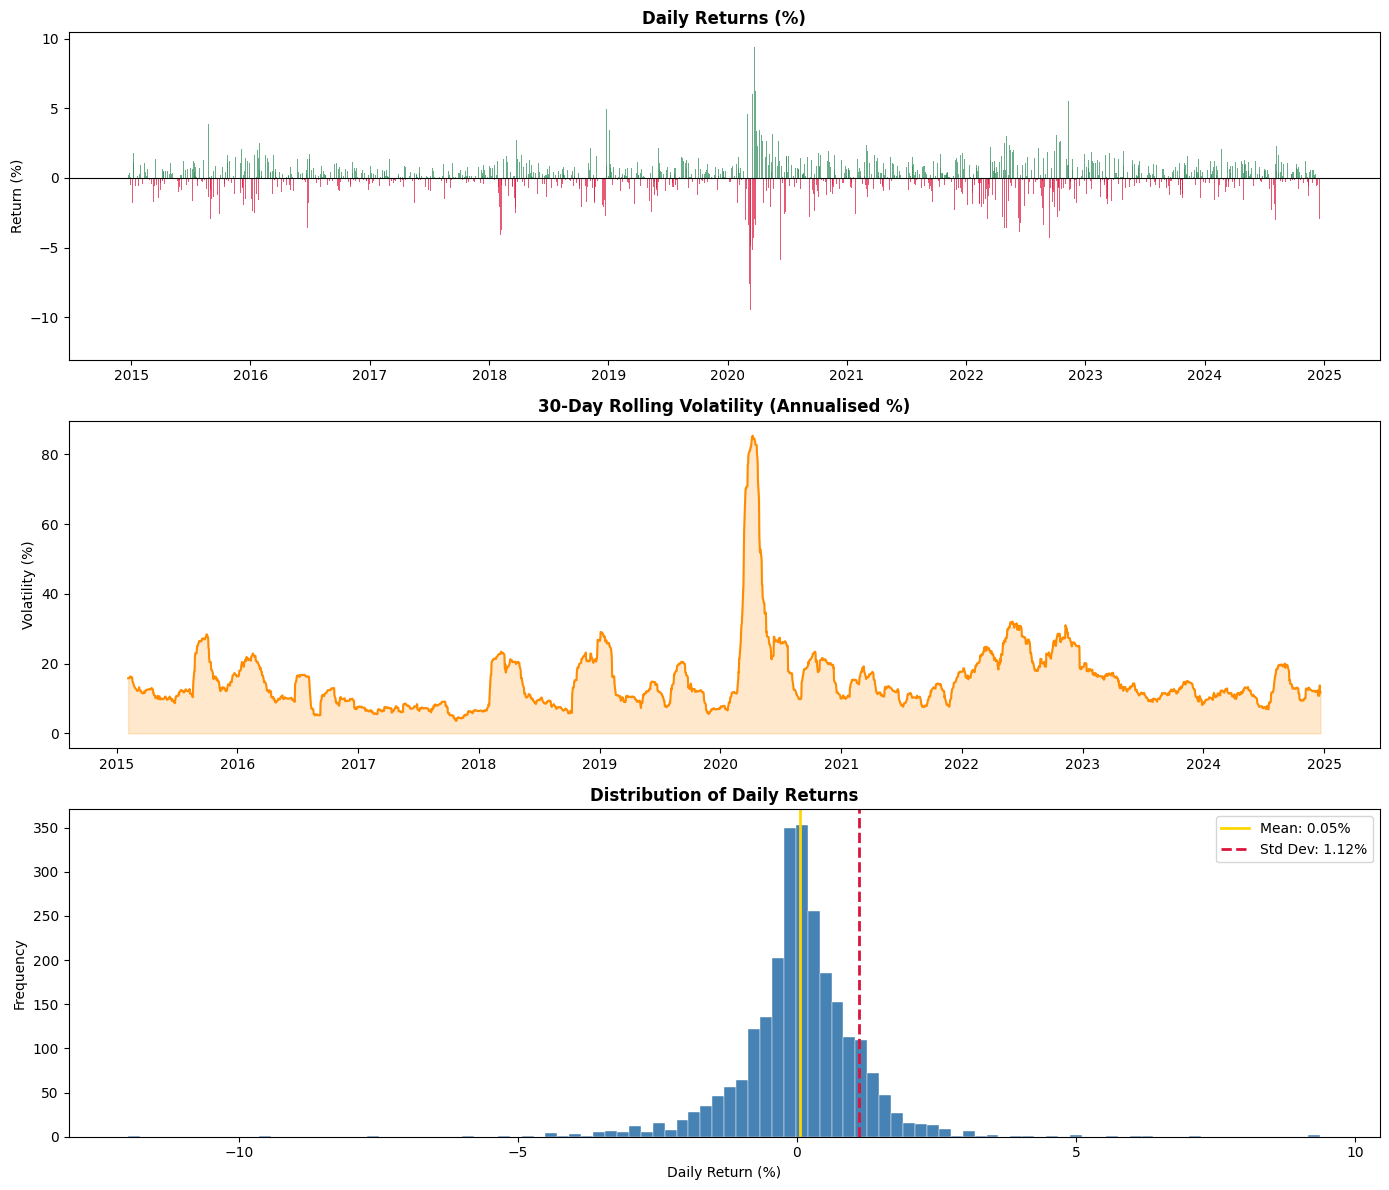

year  avg_daily_return  best_day  worst_day  up_days  down_days
2014            -0.157      0.33      -1.03        3          3
2015             0.002      3.90      -3.94      119        133
2016             0.040      2.48      -3.59      131        121
2017             0.072      1.37      -1.82      143        107
2018            -0.020      4.96      -4.10      132        119
2019             0.104      3.43      -2.98      150        102
2020             0.083      9.38     -11.98      145        108
2021             0.098      2.38      -2.57      143        109
2022            -0.075      5.54      -4.32      108        143
2023             0.090      2.28      -2.00      137        113
2024             0.092      2.53      -3.00      141        105


In [12]:
# --- Daily Returns & Volatility ---
conn = sqlite3.connect("db/sp500.db")
df = pd.read_sql_query("SELECT * FROM sp500", conn)
conn.close()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Calculate daily returns
df["daily_return"] = df["S&P500"].pct_change() * 100

# Rolling 30-day volatility (annualised)
df["volatility_30d"] = df["daily_return"].rolling(window=30).std() * (252 ** 0.5)

# --- Plot 1: Daily Returns ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].bar(df["Date"], df["daily_return"],
            color=["seagreen" if r >= 0 else "crimson" for r in df["daily_return"]],
            width=1.5, alpha=0.7)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Daily Returns (%)", fontweight="bold")
axes[0].set_ylabel("Return (%)")

# --- Plot 2: Rolling Volatility ---
axes[1].plot(df["Date"], df["volatility_30d"], color="darkorange", linewidth=1.5)
axes[1].fill_between(df["Date"], df["volatility_30d"], alpha=0.2, color="darkorange")
axes[1].set_title("30-Day Rolling Volatility (Annualised %)", fontweight="bold")
axes[1].set_ylabel("Volatility (%)")

# --- Plot 3: Return Distribution ---
axes[2].hist(df["daily_return"].dropna(), bins=100, color="steelblue",
             edgecolor="white", linewidth=0.3)
axes[2].axvline(df["daily_return"].mean(), color="gold",
                linewidth=2, label=f'Mean: {df["daily_return"].mean():.2f}%')
axes[2].axvline(df["daily_return"].std(), color="crimson", linestyle="--",
                linewidth=2, label=f'Std Dev: {df["daily_return"].std():.2f}%')
axes[2].set_title("Distribution of Daily Returns", fontweight="bold")
axes[2].set_xlabel("Daily Return (%)")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.savefig("sp500_returns_volatility.png")
plt.show()

# --- Print summary stats via SQL ---
conn = sqlite3.connect("db/sp500.db")
df.to_sql("sp500_enriched", conn, if_exists="replace", index=False)

query = """
    SELECT
        strftime('%Y', Date) AS year,
        ROUND(AVG(daily_return), 3) AS avg_daily_return,
        ROUND(MAX(daily_return), 2) AS best_day,
        ROUND(MIN(daily_return), 2) AS worst_day,
        COUNT(CASE WHEN daily_return > 0 THEN 1 END) AS up_days,
        COUNT(CASE WHEN daily_return < 0 THEN 1 END) AS down_days
    FROM sp500_enriched
    WHERE daily_return IS NOT NULL
    GROUP BY year
    ORDER BY year
"""
summary = pd.read_sql_query(query, conn)
conn.close()
print(summary.to_string(index=False))

=== Overall Sharpe Ratio (2014–2024) ===
Avg Annual Return : 12.10%
Annual Volatility : 17.82%
Sharpe Ratio      : 0.455

=== Yearly Sharpe Ratios ===
 year  annual_return_pct  volatility_pct  sharpe_ratio
 2014             -39.57            8.10        -5.379
 2015               0.47           15.49        -0.228
 2016               9.96           13.09         0.455
 2017              18.05            6.69         2.101
 2018              -5.01           17.05        -0.529
 2019              26.16           12.46         1.778
 2020              20.97           34.43         0.493
 2021              24.68           13.10         1.579
 2022             -18.79           24.17        -0.943
 2023              22.73           13.09         1.431
 2024              23.12           12.62         1.515


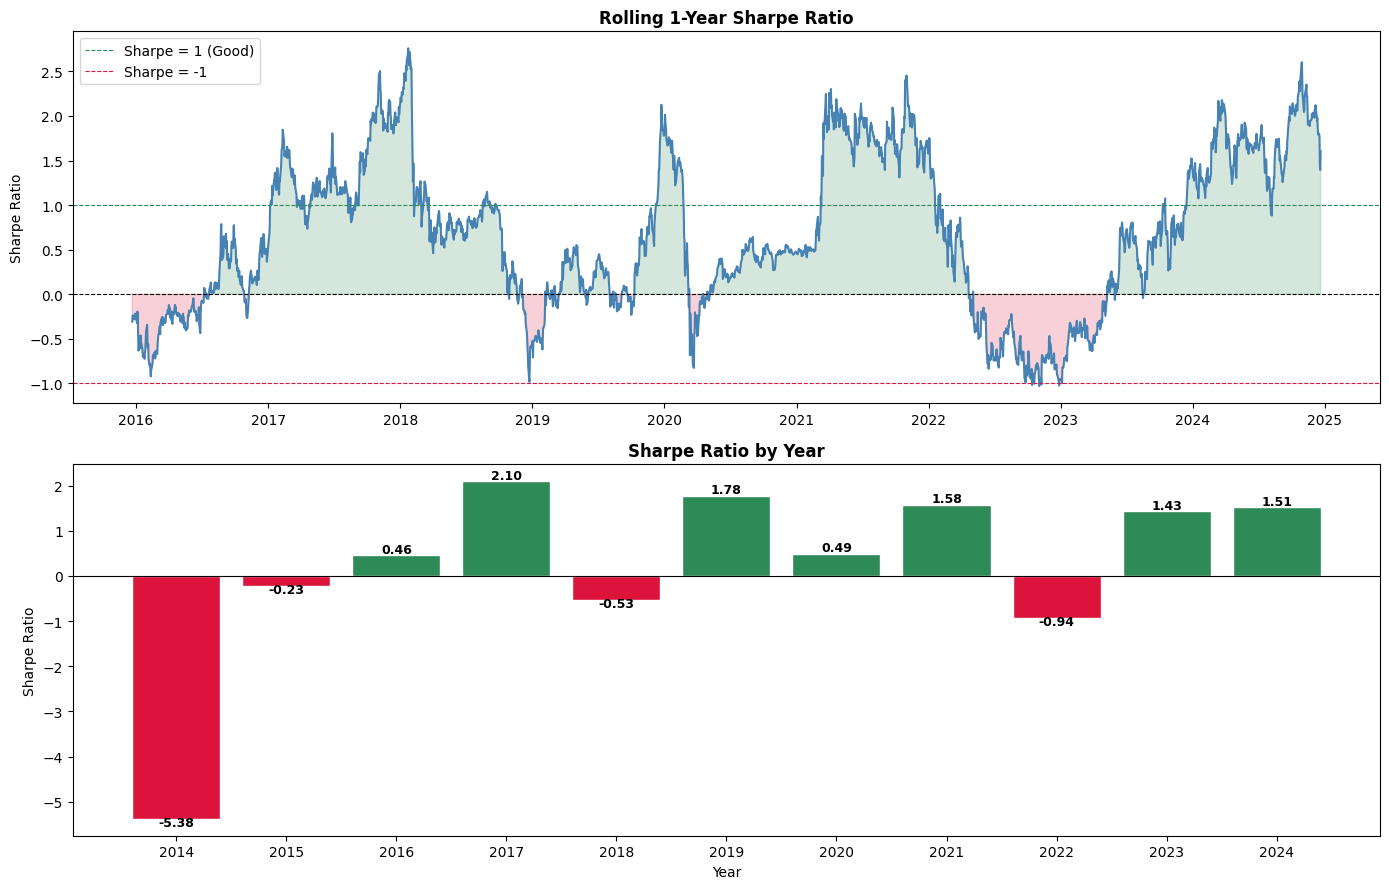

In [14]:
# --- Sharpe Ratio ---
conn = sqlite3.connect("db/sp500.db")
df = pd.read_sql_query("SELECT * FROM sp500", conn)
conn.close()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df["daily_return"] = df["S&P500"].pct_change()
df["year"] = df["Date"].dt.year

# Risk-free rate (approximate US Treasury average over period)
risk_free_rate = 0.04  # 4% annual

# --- Overall Sharpe Ratio ---
avg_annual_return = df["daily_return"].mean() * 252
annual_volatility = df["daily_return"].std() * (252 ** 0.5)
sharpe_overall = (avg_annual_return - risk_free_rate) / annual_volatility

print(f"=== Overall Sharpe Ratio (2014–2024) ===")
print(f"Avg Annual Return : {avg_annual_return*100:.2f}%")
print(f"Annual Volatility : {annual_volatility*100:.2f}%")
print(f"Sharpe Ratio      : {sharpe_overall:.3f}")
print()

# --- Rolling 1-year Sharpe Ratio ---
rolling_window = 252  # trading days in a year
df["rolling_return"] = df["daily_return"].rolling(rolling_window).mean() * 252
df["rolling_vol"] = df["daily_return"].rolling(rolling_window).std() * (252 ** 0.5)
df["rolling_sharpe"] = (df["rolling_return"] - risk_free_rate) / df["rolling_vol"]

# --- Yearly Sharpe via Pandas ---
# Calculate annual average daily return and annual std dev of daily return
yearly_stats_df = df.groupby("year")["daily_return"].agg(
    avg_daily_return = "mean",
    std_daily_return = "std"
).reset_index()

# Annualize them
yearly_stats_df["annual_return"] = yearly_stats_df["avg_daily_return"] * 252
yearly_stats_df["annual_volatility"] = yearly_stats_df["std_daily_return"] * (252 ** 0.5)

# Calculate Sharpe Ratio
yearly_stats_df["sharpe_ratio"] = (yearly_stats_df["annual_return"] - risk_free_rate) / yearly_stats_df["annual_volatility"]

# Filter out years with insufficient data for standard deviation (e.g., only one daily return)
yearly_stats_df = yearly_stats_df.dropna(subset=["sharpe_ratio"])

# Prepare for printing and plotting (match previous output format)
yearly_sharpe = yearly_stats_df.copy()
yearly_sharpe["annual_return_pct"] = (yearly_sharpe["annual_return"] * 100).round(2)
yearly_sharpe["volatility_pct"] = (yearly_sharpe["annual_volatility"] * 100).round(2)
yearly_sharpe["sharpe_ratio"] = yearly_sharpe["sharpe_ratio"].round(3)

print("=== Yearly Sharpe Ratios ===")
print(yearly_sharpe[["year", "annual_return_pct", "volatility_pct", "sharpe_ratio"]].to_string(index=False))

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Rolling Sharpe
axes[0].plot(df["Date"], df["rolling_sharpe"], color="steelblue", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].axhline(1, color="seagreen", linewidth=0.8, linestyle="--", label="Sharpe = 1 (Good)")
axes[0].axhline(-1, color="crimson", linewidth=0.8, linestyle="--", label="Sharpe = -1")
axes[0].fill_between(df["Date"], df["rolling_sharpe"], 0,
                     where=df["rolling_sharpe"] >= 0, alpha=0.2, color="seagreen")
axes[0].fill_between(df["Date"], df["rolling_sharpe"], 0,
                     where=df["rolling_sharpe"] < 0, alpha=0.2, color="crimson")
axes[0].set_title("Rolling 1-Year Sharpe Ratio", fontweight="bold")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].legend()

# Yearly Sharpe bar chart
colors = ["seagreen" if s >= 0 else "crimson" for s in yearly_sharpe["sharpe_ratio"]]
bars = axes[1].bar(yearly_sharpe["year"], yearly_sharpe["sharpe_ratio"],
                   color=colors, edgecolor="white")
for bar, val in zip(bars, yearly_sharpe["sharpe_ratio"]):
    ypos = bar.get_height() + 0.05 if val >= 0 else bar.get_height() - 0.15
    axes[1].text(bar.get_x() + bar.get_width() / 2, ypos, f"{val:.2f}",
                 ha="center", fontsize=9, fontweight="bold")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Sharpe Ratio by Year", fontweight="bold")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_xlabel("Year")
axes[1].set_xticks(yearly_sharpe["year"])

plt.tight_layout()
plt.savefig("sp500_sharpe_ratio.png")
plt.show()

**Final Dashboard:**

/tmp/ipykernel_2881/1860782724.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_sharpe = df.groupby("year").apply(calc_sharpe).reset_index()


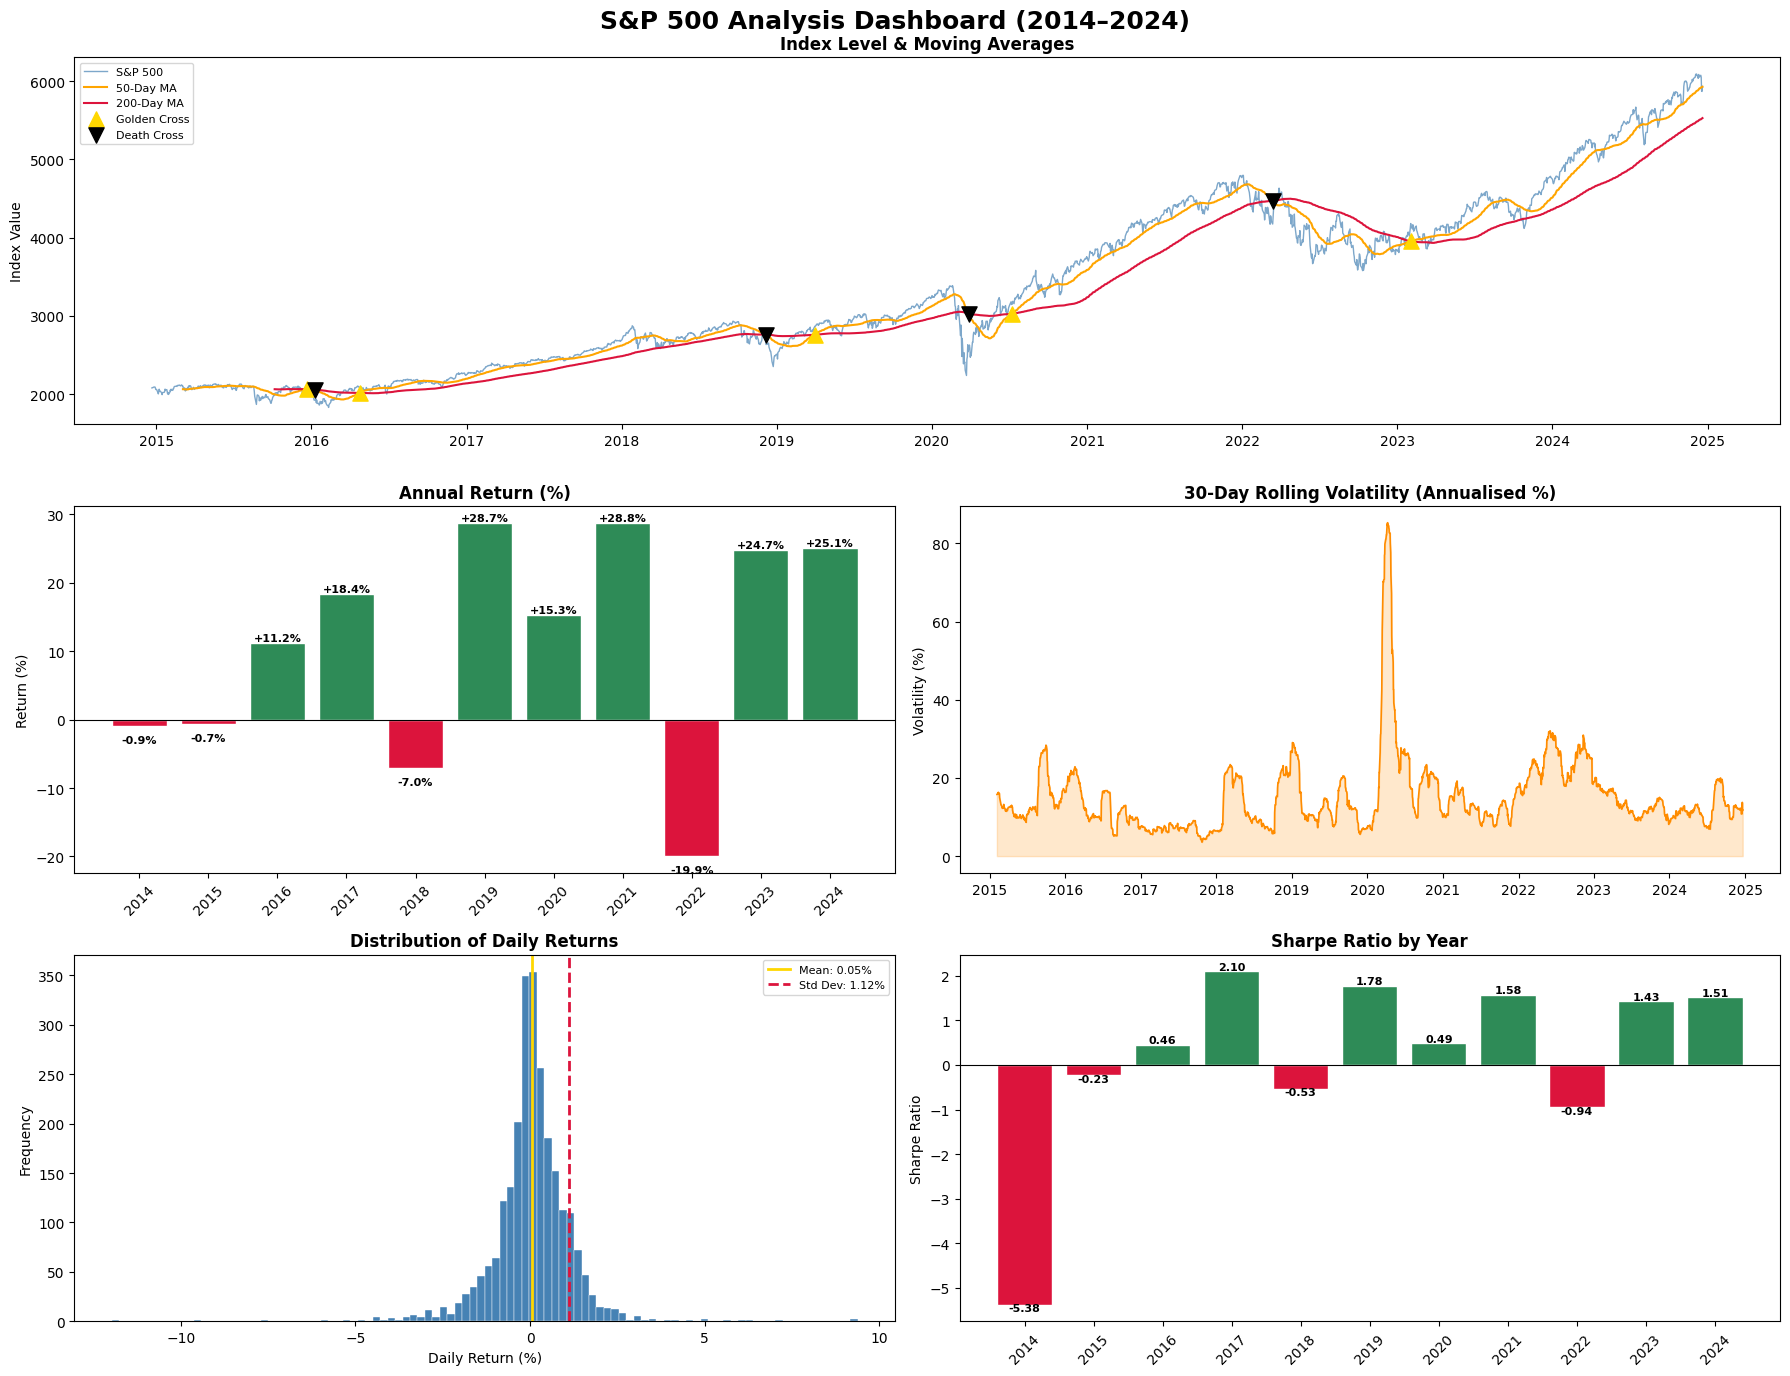

Dashboard saved as sp500_dashboard.png ✓


In [15]:
# --- Final Dashboard ---
conn = sqlite3.connect("db/sp500.db")
df = pd.read_sql_query("SELECT * FROM sp500", conn)
conn.close()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df["daily_return"] = df["S&P500"].pct_change()
df["year"] = df["Date"].dt.year
df["MA50"] = df["S&P500"].rolling(50).mean()
df["MA200"] = df["S&P500"].rolling(200).mean()
df["volatility_30d"] = df["daily_return"].rolling(30).std() * (252 ** 0.5) * 100
df["rolling_sharpe"] = (
    (df["daily_return"].rolling(252).mean() * 252 - 0.04) /
    (df["daily_return"].rolling(252).std() * (252 ** 0.5))
)

# Yearly returns
yearly = df.groupby("year")["S&P500"].agg(["first", "last"]).reset_index()
yearly.columns = ["year", "start", "end"]
yearly["return_pct"] = ((yearly["end"] - yearly["start"]) / yearly["start"] * 100).round(2)

# Yearly Sharpe
risk_free_rate = 0.04
def calc_sharpe(group):
    ann_return = group["daily_return"].mean() * 252
    ann_vol = group["daily_return"].std() * (252 ** 0.5)
    return round((ann_return - risk_free_rate) / ann_vol, 3)
yearly_sharpe = df.groupby("year").apply(calc_sharpe).reset_index()
yearly_sharpe.columns = ["year", "sharpe_ratio"]

# --- Build Dashboard ---
fig = plt.figure(figsize=(18, 14))
fig.suptitle("S&P 500 Analysis Dashboard (2014–2024)",
             fontsize=18, fontweight="bold", y=0.98)

# Colour helpers
ret_colors = ["seagreen" if r >= 0 else "crimson" for r in yearly["return_pct"]]
sharpe_colors = ["seagreen" if s >= 0 else "crimson" for s in yearly_sharpe["sharpe_ratio"]]

# --- Panel 1: Index + Moving Averages (top, full width) ---
ax1 = fig.add_subplot(3, 2, (1, 2))
ax1.plot(df["Date"], df["S&P500"], color="steelblue", linewidth=1, alpha=0.7, label="S&P 500")
ax1.plot(df["Date"], df["MA50"], color="orange", linewidth=1.5, label="50-Day MA")
ax1.plot(df["Date"], df["MA200"], color="crimson", linewidth=1.5, label="200-Day MA")
golden = df[(df["MA50"] > df["MA200"]) & (df["MA50"].shift(1) <= df["MA200"].shift(1))]
death = df[(df["MA50"] < df["MA200"]) & (df["MA50"].shift(1) >= df["MA200"].shift(1))]
ax1.scatter(golden["Date"], golden["MA50"], marker="^", color="gold", zorder=5, s=120, label="Golden Cross")
ax1.scatter(death["Date"], death["MA50"], marker="v", color="black", zorder=5, s=120, label="Death Cross")
ax1.set_title("Index Level & Moving Averages", fontweight="bold")
ax1.set_ylabel("Index Value")
ax1.legend(loc="upper left", fontsize=8)

# --- Panel 2: Annual Returns ---
ax2 = fig.add_subplot(3, 2, 3)
bars = ax2.bar(yearly["year"], yearly["return_pct"], color=ret_colors, edgecolor="white")
for bar, val in zip(bars, yearly["return_pct"]):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 2.5
    ax2.text(bar.get_x() + bar.get_width() / 2, ypos, f"{val:+.1f}%",
             ha="center", fontsize=8, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Annual Return (%)", fontweight="bold")
ax2.set_ylabel("Return (%)")
ax2.set_xticks(yearly["year"])
ax2.tick_params(axis="x", rotation=45)

# --- Panel 3: Rolling Volatility ---
ax3 = fig.add_subplot(3, 2, 4)
ax3.plot(df["Date"], df["volatility_30d"], color="darkorange", linewidth=1.2)
ax3.fill_between(df["Date"], df["volatility_30d"], alpha=0.2, color="darkorange")
ax3.set_title("30-Day Rolling Volatility (Annualised %)", fontweight="bold")
ax3.set_ylabel("Volatility (%)")

# --- Panel 4: Return Distribution ---
ax4 = fig.add_subplot(3, 2, 5)
ax4.hist(df["daily_return"].dropna() * 100, bins=100,
         color="steelblue", edgecolor="white", linewidth=0.3)
ax4.axvline(df["daily_return"].mean() * 100, color="gold",
            linewidth=2, label=f'Mean: {df["daily_return"].mean()*100:.2f}%')
ax4.axvline(df["daily_return"].std() * 100, color="crimson", linestyle="--",
            linewidth=2, label=f'Std Dev: {df["daily_return"].std()*100:.2f}%')
ax4.set_title("Distribution of Daily Returns", fontweight="bold")
ax4.set_xlabel("Daily Return (%)")
ax4.set_ylabel("Frequency")
ax4.legend(fontsize=8)

# --- Panel 5: Yearly Sharpe Ratio ---
ax5 = fig.add_subplot(3, 2, 6)
bars5 = ax5.bar(yearly_sharpe["year"], yearly_sharpe["sharpe_ratio"],
                color=sharpe_colors, edgecolor="white")
for bar, val in zip(bars5, yearly_sharpe["sharpe_ratio"]):
    ypos = bar.get_height() + 0.03 if val >= 0 else bar.get_height() - 0.15
    ax5.text(bar.get_x() + bar.get_width() / 2, ypos, f"{val:.2f}",
             ha="center", fontsize=8, fontweight="bold")
ax5.axhline(0, color="black", linewidth=0.8)
ax5.set_title("Sharpe Ratio by Year", fontweight="bold")
ax5.set_ylabel("Sharpe Ratio")
ax5.set_xticks(yearly_sharpe["year"])
ax5.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("sp500_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as sp500_dashboard.png ✓")